### The PowerGrid "Chronics" Dataset 


## Setup path

In [21]:
import os

CHRONICS_PATH = "D:\chronics\chronics"  # <-- change this

def read_csv(path):
    for ext in ['.csv.bz2', '.csv']:
        if os.path.exists(path + ext):
            return pd.read_csv(path + ext, sep=';')
    return None

# Check it exists
folders = sorted([f for f in os.listdir(CHRONICS_PATH) if os.path.isdir(os.path.join(CHRONICS_PATH, f))])
print(f"✅ Found {len(folders)} scenario folders")
print(f"First 5: {folders[:5]}")
print(f"Last 5:  {folders[-5:]}")

✅ Found 1014 scenario folders
First 5: ['0000', '0001', '0002', '0003', '0004']
Last 5:  ['1009', '1010', '1011', '1012', '1013']


In [9]:
import pandas as pd
sample_folder = os.path.join("D:\chronics\chronics", folders[0])
files_inside = os.listdir(sample_folder)
print("Files inside one scenario folder:")
for f in sorted(files_inside):
    print(f"   {f}")

Files inside one scenario folder:
   load_p.csv
   load_p_forecasted.csv
   load_q.csv
   load_q_forecasted.csv
   prod_p.csv
   prod_p_forecasted.csv
   prod_v.csv
   prod_v_forecasted.csv
   start_datetime.info
   time_interval.info


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Admin\AppData\Local\Temp\ipykernel_14752\217056481.py:2: SyntaxWarning: invalid escape sequence '\c'
  sample_folder = os.path.join("D:\chronics\chronics", folders[0])


## Library Setup

In [11]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.5,
    'font.size':        11,
})

C_EASY   = '#16a34a'
C_MEDIUM = '#f59e0b'
C_HARD   = '#dc2626'
C_BLUE   = '#2563eb'
C_PURPLE = '#7c3aed'

print('✅ Libraries loaded')

✅ Libraries loaded


## What are inside this folder?
- There are **1014 folders** (`0000` to `1013`).
- Each folder = **one realistic week** of the power grid (5-minute steps → 8065 rows).
- Inside every folder you will find:
  - `load_p.csv` → How much electricity **consumers** are using (MW)
  - `load_q.csv` → Reactive power
  - `prod_p.csv` → How much electricity **generators** are producing
  - Forecast files + start time info

In [8]:
import os

CHRONICS_PATH = "D:\chronics\chronics"
folders = sorted([f for f in os.listdir(CHRONICS_PATH) if os.path.isdir(os.path.join(CHRONICS_PATH, f))])
print(f"Found {len(folders)} scenario folders")
print(f"First 5: {folders[:5]}")
print(f"Last 5:  {folders[-5:]}")

Found 1014 scenario folders
First 5: ['0000', '0001', '0002', '0003', '0004']
Last 5:  ['1009', '1010', '1011', '1012', '1013']


<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Admin\AppData\Local\Temp\ipykernel_14752\466551151.py:3: SyntaxWarning: invalid escape sequence '\c'
  CHRONICS_PATH = "D:\chronics\chronics"


In [3]:
load_p_path = os.path.join(sample_folder, "load_p.csv.bz2")
try:
    load_p = pd.read_csv(load_p_path, sep=";") 
except FileNotFoundError:
    load_p = pd.read_csv(load_p_path.replace(".bz2", ""), sep=";")

print(f"Shape: {load_p.shape}  →  {load_p.shape[0]} timesteps × {load_p.shape[1]} load buses")
print(f"\nEach row = 5 minutes. Total duration = {load_p.shape[0] * 5 / 60:.1f} hours = ~1 week")
print(f"\nFirst 3 rows:")
load_p.head(3)

Shape: (8065, 11)  →  8065 timesteps × 11 load buses

Each row = 5 minutes. Total duration = 672.1 hours = ~1 week

First 3 rows:


,load_1_0,load_2_1,load_3_2,load_4_3,load_5_4,load_8_5,load_9_6,load_10_7,load_11_8,load_12_9,load_13_10
0,22.0,87.0,45.8,7.0,12.0,28.2,8.7,3.5,5.5,12.7,14.8
1,22.1,89.0,45.9,6.9,12.3,28.4,8.8,3.4,5.5,12.9,15.2
2,22.2,88.1,45.0,6.9,12.2,28.1,8.9,3.4,5.5,12.8,15.1


# Quick summary of one scenario

In [4]:
print("=== WHAT EACH NUMBER MEANS ===")
print(f"Each column = one load (consumer) on the grid")
print(f"Each value  = MW of power being consumed at that 5-min step\n")
print(load_p.describe().round(2))

=== WHAT EACH NUMBER MEANS ===
Each column = one load (consumer) on the grid
Each value  = MW of power being consumed at that 5-min step

       load_1_0  load_2_1  load_3_2  load_4_3  load_5_4  load_8_5  load_9_6  \
count   8065.00   8065.00   8065.00   8065.00   8065.00   8065.00   8065.00   
mean      21.51     93.78     47.40      7.53     11.13     29.31      8.93   
std        1.84      8.87      4.72      0.73      0.86      2.70      0.93   
min       17.00     70.40     36.00      5.60      8.70     22.30      6.80   
25%       20.10     87.50     43.80      7.00     10.50     27.20      8.20   
50%       21.70     94.20     47.70      7.60     11.20     29.60      8.90   
75%       22.90    100.40     50.90      8.10     11.80     31.40      9.70   
max       26.40    115.80     60.50      9.40     13.30     36.10     11.40   

       load_10_7  load_11_8  load_12_9  load_13_10  
count    8065.00    8065.00    8065.00     8065.00  
mean        3.46       6.04      13.41      

## Summary Table

In [25]:
print('Building master summary table...')
records = []

for name in tqdm(folders):
    fp   = os.path.join(CHRONICS_PATH, name)
    row  = {'scenario': name}

    # ── load_p ──────────────────────────────────────
    lp = read_csv(os.path.join(fp, 'load_p'))
    if lp is not None:
        t = lp.sum(axis=1)
        row['load_mean_mw']    = round(t.mean(), 2)
        row['load_max_mw']     = round(t.max(),  2)
        row['load_min_mw']     = round(t.min(),  2)
        row['load_std_mw']     = round(t.std(),  2)
        row['load_peak_ratio'] = round(t.max() / t.mean(), 4)
        row['n_timesteps']     = len(t)
        # Peak hour (most common high-demand hour)
        spd = 288
        n_d = len(t) // spd
        if n_d > 0:
            daily_avg = t.values[:n_d*spd].reshape(n_d, spd).mean(axis=0)
            row['peak_hour'] = round(daily_avg.argmax() * 5 / 60, 1)

    # ── load_q ──────────────────────────────────────
    lq = read_csv(os.path.join(fp, 'load_q'))
    if lq is not None and lp is not None:
        q_total = lq.sum(axis=1)
        p_total = lp.sum(axis=1)
        ratio   = q_total / (p_total + 1e-6)
        row['reactive_burden'] = round(ratio.mean(), 4)  # load_q / load_p

    # ── prod_p ──────────────────────────────────────
    pp = read_csv(os.path.join(fp, 'prod_p'))
    if pp is not None:
        gen = pp.sum(axis=1)
        row['gen_mean_mw'] = round(gen.mean(), 2)
        row['gen_max_mw']  = round(gen.max(),  2)
        row['gen_std_mw']  = round(gen.std(),  2)

        # Ramp rate (lag distribution KPI)
        ramp = gen.diff().abs().dropna()
        row['ramp_mean_mw']  = round(ramp.mean(), 2)
        row['ramp_max_mw']   = round(ramp.max(),  2)

        # High utilization: timesteps where any generator > 80% of its max
        gen_max_per_col = pp.max()
        overload_mask   = (pp > 0.8 * gen_max_per_col).any(axis=1)
        row['high_util_pct'] = round(overload_mask.mean() * 100, 2)

        # Supply-demand imbalance
        if lp is not None:
            imb = (gen - lp.sum(axis=1)).abs()
            row['imbalance_mean'] = round(imb.mean(), 2)
            row['imbalance_max']  = round(imb.max(),  2)

    # ── prod_v ──────────────────────────────────────
    pv = read_csv(os.path.join(fp, 'prod_v'))
    if pv is not None:
        # Voltage deviation from nominal (1.0 pu)
        dev = (pv - 1.0).abs()
        row['voltage_dev_mean'] = round(dev.mean().mean(), 4)
        row['voltage_dev_max']  = round(dev.max().max(),   4)

    # ── hazards ─────────────────────────────────────
    hz = read_csv(os.path.join(fp, 'hazards'))
    if hz is not None:
        row['hazard_events']    = int((hz > 0).sum().sum())
        row['hazard_lines']     = int((hz > 0).any().sum())

    # ── maintenance ─────────────────────────────────
    mt = read_csv(os.path.join(fp, 'maintenance'))
    if mt is not None:
        row['maint_events']     = int((mt > 0).sum().sum())

    records.append(row)

summary = pd.DataFrame(records)
print(f'\n✅ Summary table: {summary.shape[0]} scenarios × {summary.shape[1]} KPI columns')
summary.head(3)

Building master summary table...


100%|██████████████████████████████████████████████████████████████████████████████| 1014/1014 [02:22<00:00,  7.11it/s]



✅ Summary table: 1014 scenarios × 19 KPI columns


,scenario,load_mean_mw,load_max_mw,load_min_mw,load_std_mw,load_peak_ratio,n_timesteps,peak_hour,reactive_burden,gen_mean_mw,gen_max_mw,gen_std_mw,ramp_mean_mw,ramp_max_mw,high_util_pct,imbalance_mean,imbalance_max,voltage_dev_mean,voltage_dev_max
0,0000,257.33,306.3,203.9,22.53,1.1903,8065,19.4,0.7,262.24,314.7,23.00,1.72,9.5,48.77,4.92,11.7,79.5833,141.1
1,0001,258.21,321.6,199.6,22.85,1.2455,8065,19.2,0.7,263.12,328.6,23.31,1.74,8.4,41.62,4.92,13.6,79.5833,141.1
2,0002,256.02,311.7,190.7,23.16,1.2175,8065,19.3,0.7,260.88,319.1,23.60,1.71,8.1,49.80,4.86,12.1,79.5833,141.1


## Daily peak level of the data

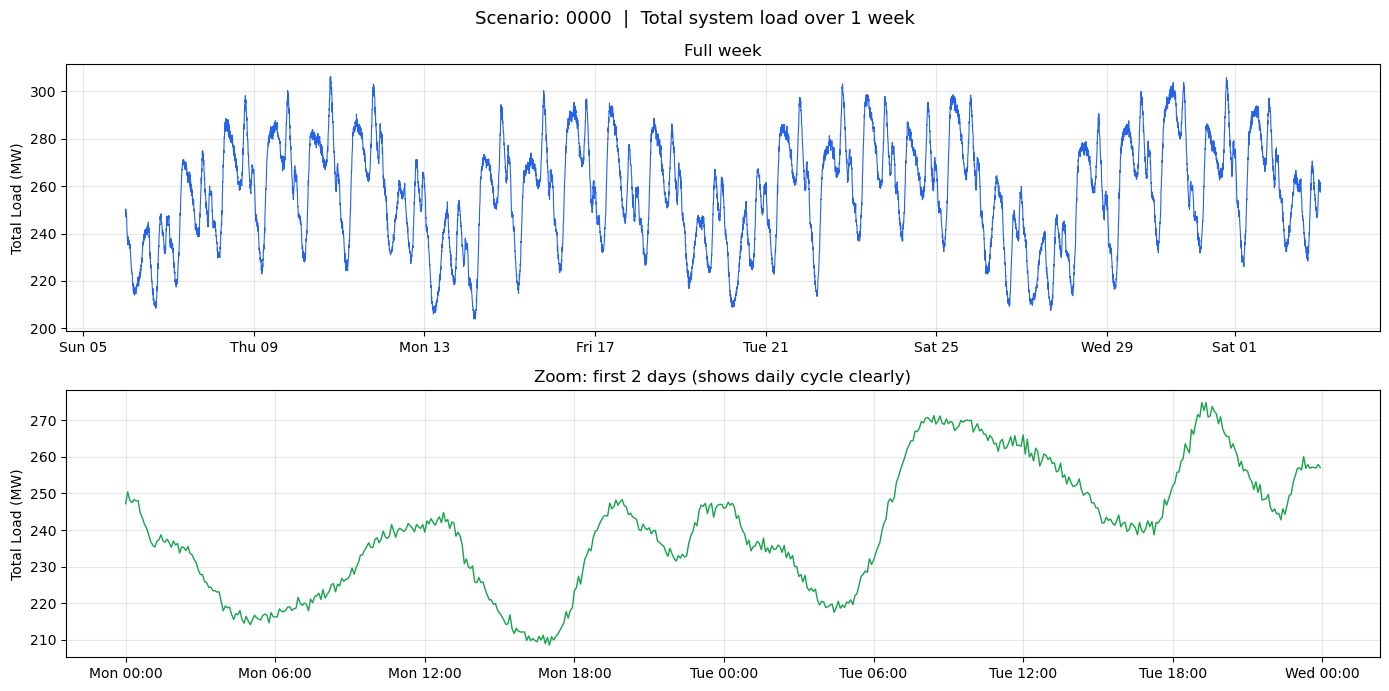

Notice the daily peaks (morning/evening) and the weekly pattern!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

total_load = load_p.sum(axis=1)
time_index = pd.date_range(start="2020-01-06", periods=len(total_load), freq="5min")
total_load.index = time_index

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f"Scenario: {folders[0]}  |  Total system load over 1 week", fontsize=13)

axes[0].plot(total_load, color="#2563eb", linewidth=0.8)
axes[0].set_ylabel("Total Load (MW)")
axes[0].set_title("Full week")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(total_load.iloc[:576], color="#16a34a", linewidth=1)
axes[1].set_ylabel("Total Load (MW)")
axes[1].set_title("Zoom: first 2 days (shows daily cycle clearly)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("one_scenario_load.png", dpi=120, bbox_inches="tight")
plt.show()
print("Notice the daily peaks (morning/evening) and the weekly pattern!")

## Weekly Load Profile

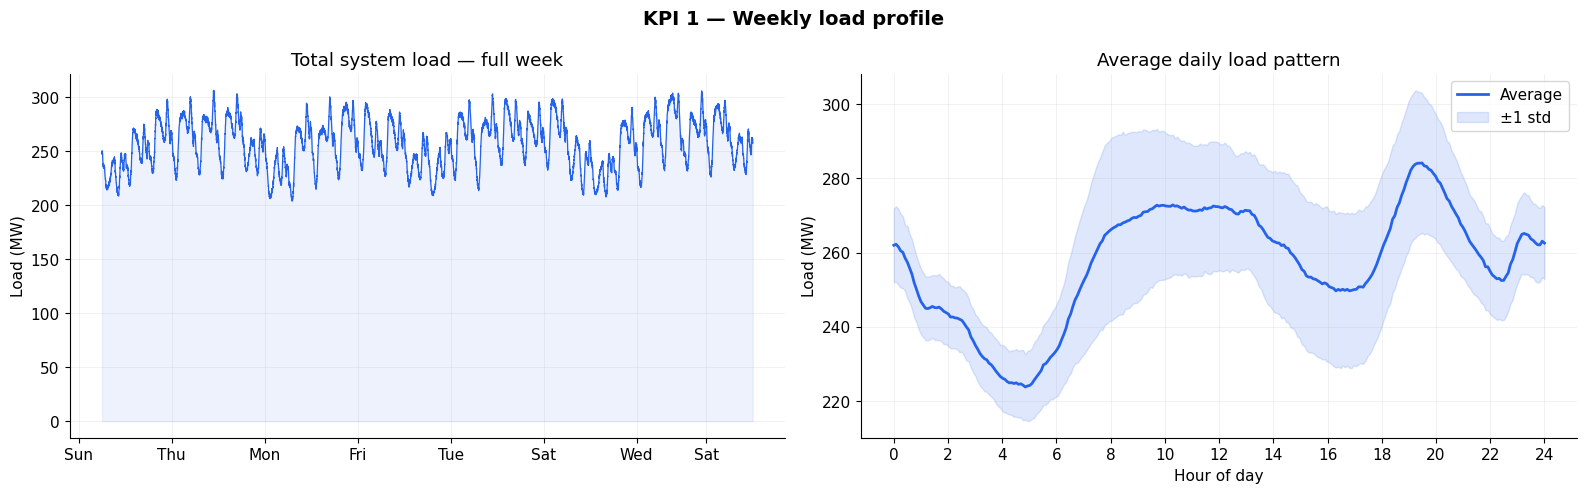

Saved:weekly_load_profile.png


In [13]:

total_load = load_p.sum(axis=1)
time_idx   = pd.date_range('2020-01-06', periods=len(total_load), freq='5min')
total_load.index = time_idx

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('KPI 1 — Weekly load profile', fontsize=14, fontweight='bold')


axes[0].plot(total_load, color=C_BLUE, linewidth=0.9)
axes[0].fill_between(total_load.index, total_load, alpha=0.08, color=C_BLUE)
axes[0].set_title('Total system load — full week')
axes[0].set_ylabel('Load (MW)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%a'))


spd = 288
vals = total_load.values
n_days = len(vals) // spd
daily  = vals[:n_days * spd].reshape(n_days, spd)
avg_day = daily.mean(axis=0)
std_day = daily.std(axis=0)
hours   = np.linspace(0, 24, spd)

axes[1].plot(hours, avg_day, color=C_BLUE, linewidth=2, label='Average')
axes[1].fill_between(hours, avg_day - std_day, avg_day + std_day,
                     alpha=0.15, color=C_BLUE, label='±1 std')
axes[1].set_title('Average daily load pattern')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Load (MW)')
axes[1].set_xticks(range(0, 25, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig('weekly_load_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:weekly_load_profile.png')

## Difficulty Level Distribution

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Difficulty = combination of:
#   high peak load  → grid under stress
#   high load std   → unpredictable demand
#   high imbalance  → dispatch is struggling
#   more hazards    → more failures to handle

difficulty_cols = []

if "load_peak_ratio" in summary.columns:
    difficulty_cols.append("load_peak_ratio")
if "load_std_mw" in summary.columns:
    difficulty_cols.append("load_std_mw")
if "imbalance_mean" in summary.columns:
    difficulty_cols.append("imbalance_mean")
if "hazards_events" in summary.columns:
    difficulty_cols.append("hazards_events")
if "maintenance_events" in summary.columns:
    difficulty_cols.append("maintenance_events")

print(f"Using these features for difficulty: {difficulty_cols}")

# Normalize each to [0, 1] and average
scaler = MinMaxScaler()
subset = summary[difficulty_cols].fillna(0)
normalized = scaler.fit_transform(subset)
summary["difficulty_score"] = normalized.mean(axis=1)

# Label easy / medium / hard
summary["difficulty_label"] = pd.cut(
    summary["difficulty_score"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["easy", "medium", "hard"]
)

print("\n--- Difficulty distribution ---")
print(summary["difficulty_label"].value_counts())
print("\nTop 5 hardest scenarios:")
summary.nlargest(5, "difficulty_score")[["scenario", "difficulty_score", "load_max_mw", "difficulty_label"]]

Using these features for difficulty: ['load_peak_ratio', 'load_std_mw', 'imbalance_mean']

--- Difficulty distribution ---
difficulty_label
hard      523
medium    488
easy        3
Name: count, dtype: int64

Top 5 hardest scenarios:


,scenario,difficulty_score,load_max_mw,difficulty_label
324,0324,0.844568,331.8,hard
667,0667,0.811094,327.8,hard
967,0967,0.798027,321.5,hard
737,0737,0.797150,321.8,hard
833,0833,0.795625,327.1,hard


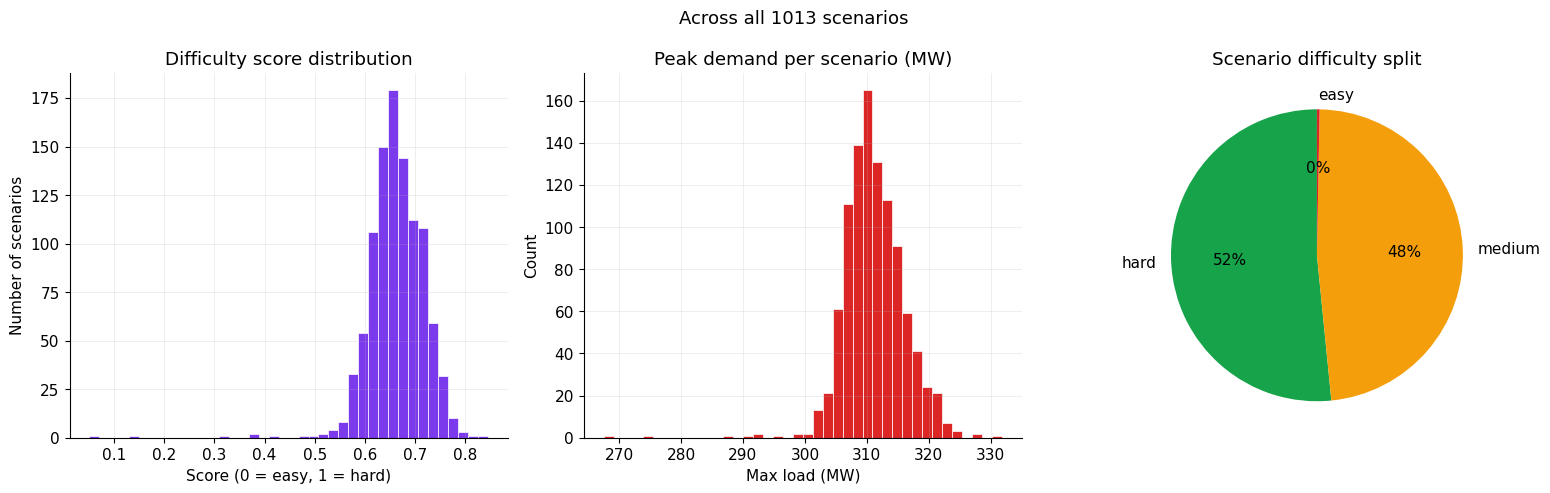

In [16]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Across all 1013 scenarios", fontsize=13)

# 1. Difficulty score distribution
axes[0].hist(summary["difficulty_score"], bins=40, color="#7c3aed", edgecolor="white", linewidth=0.5)
axes[0].set_title("Difficulty score distribution")
axes[0].set_xlabel("Score (0 = easy, 1 = hard)")
axes[0].set_ylabel("Number of scenarios")
axes[0].grid(True, alpha=0.3)

# 2. Peak load distribution
if "load_max_mw" in summary.columns:
    axes[1].hist(summary["load_max_mw"].dropna(), bins=40, color="#dc2626", edgecolor="white", linewidth=0.5)
    axes[1].set_title("Peak demand per scenario (MW)")
    axes[1].set_xlabel("Max load (MW)")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.3)

# 3. Easy / Medium / Hard pie
counts = summary["difficulty_label"].value_counts()
colors = ["#16a34a", "#f59e0b", "#dc2626"]
axes[2].pie(counts, labels=counts.index, colors=colors, autopct="%1.0f%%", startangle=90)
axes[2].set_title("Scenario difficulty split")

plt.tight_layout()
plt.savefig("difficulty_overview.png", dpi=120, bbox_inches="tight")
plt.show()

 ## Heatmap across ALL 1013 scenarios

In [23]:
print('Reading all scenarios for heatmap (takes 2-3 minutes)...')
profiles = []
valid_names = []

for name in tqdm(folders):
    lp = read_csv(os.path.join(CHRONICS_PATH, name, 'load_p'))
    if lp is None:
        continue
    total = lp.sum(axis=1).values
    spd   = 288
    n_d   = len(total) // spd
    if n_d == 0:
        continue
    avg   = total[:n_d * spd].reshape(n_d, spd).mean(axis=0)
    profiles.append(avg)
    valid_names.append(name)

heatmap_data = np.array(profiles)
print(f'\nHeatmap shape: {heatmap_data.shape}  ({heatmap_data.shape[0]} scenarios × {heatmap_data.shape[1]} 5-min steps)')

Reading all scenarios for heatmap (takes 2-3 minutes)...


100%|██████████████████████████████████████████████████████████████████████████████| 1014/1014 [00:20<00:00, 49.43it/s]


Heatmap shape: (1014, 288)  (1014 scenarios × 288 5-min steps)


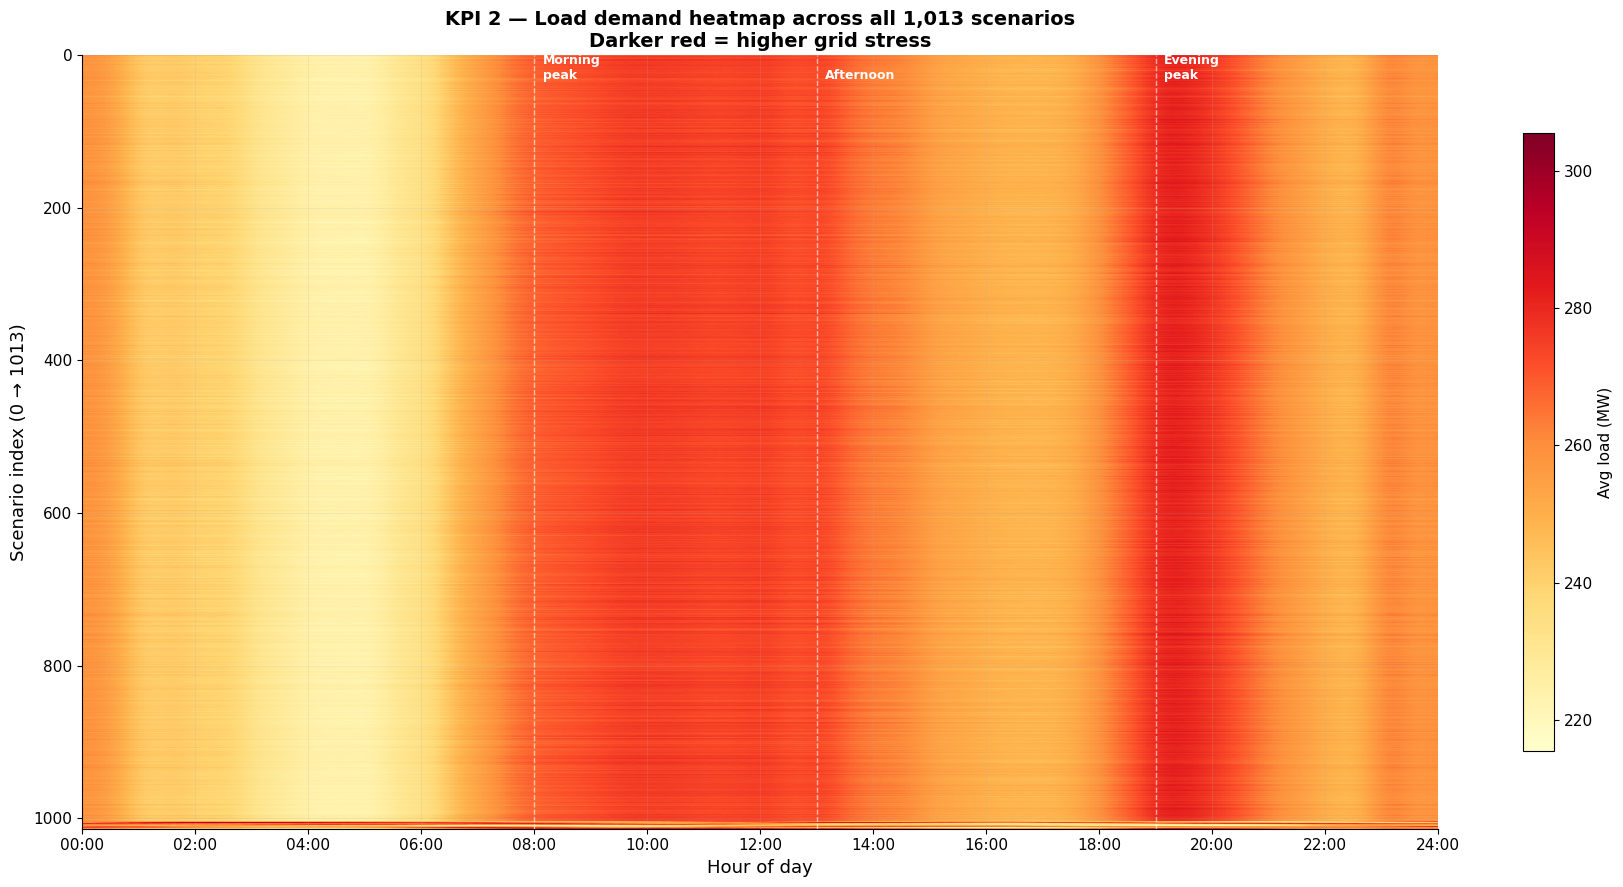

Saved:load_heatmap.png


In [24]:
fig, ax = plt.subplots(figsize=(18, 9))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
               extent=[0, 24, len(profiles), 0])

for h, label in [(8, 'Morning\npeak'), (13, 'Afternoon'), (19, 'Evening\npeak')]:
    ax.axvline(h, color='white', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(h + 0.15, len(profiles) * 0.03, label,
            color='white', fontsize=9, fontweight='bold')

ax.set_xlabel('Hour of day', fontsize=13)
ax.set_ylabel('Scenario index (0 → 1013)', fontsize=13)
ax.set_title('KPI 2 — Load demand heatmap across all 1,013 scenarios\nDarker red = higher grid stress',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
plt.colorbar(im, ax=ax, label='Avg load (MW)', shrink=0.8)

plt.tight_layout()
plt.savefig('load_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:load_heatmap.png')

## Supply-Demand Imbalance 

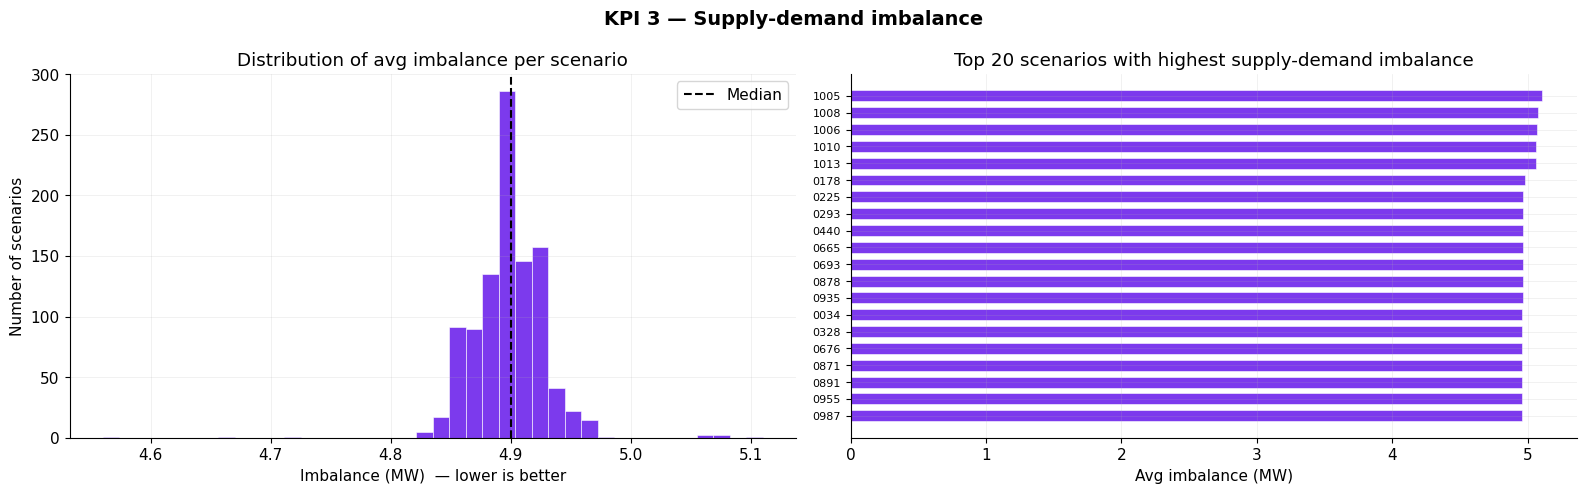

Saved: kpi3_imbalance.png


In [26]:
if 'imbalance_mean' in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('KPI 3 — Supply-demand imbalance', fontsize=14, fontweight='bold')

    axes[0].hist(summary['imbalance_mean'].dropna(), bins=40,
                 color=C_PURPLE, edgecolor='white', linewidth=0.4)
    axes[0].axvline(summary['imbalance_mean'].median(), color='black',
                    linewidth=1.5, linestyle='--', label='Median')
    axes[0].set_title('Distribution of avg imbalance per scenario')
    axes[0].set_xlabel('Imbalance (MW)  — lower is better')
    axes[0].set_ylabel('Number of scenarios')
    axes[0].legend()

    top20 = summary.nlargest(20, 'imbalance_mean')[['scenario','imbalance_mean']]
    axes[1].barh(top20['scenario'], top20['imbalance_mean'],
                 color=C_PURPLE, edgecolor='white', linewidth=0.4, height=0.65)
    axes[1].invert_yaxis()
    axes[1].set_title('Top 20 scenarios with highest supply-demand imbalance')
    axes[1].set_xlabel('Avg imbalance (MW)')
    axes[1].tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig('kpi3_imbalance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: kpi3_imbalance.png')

 ## Generator Utilization (High/Low utilization)

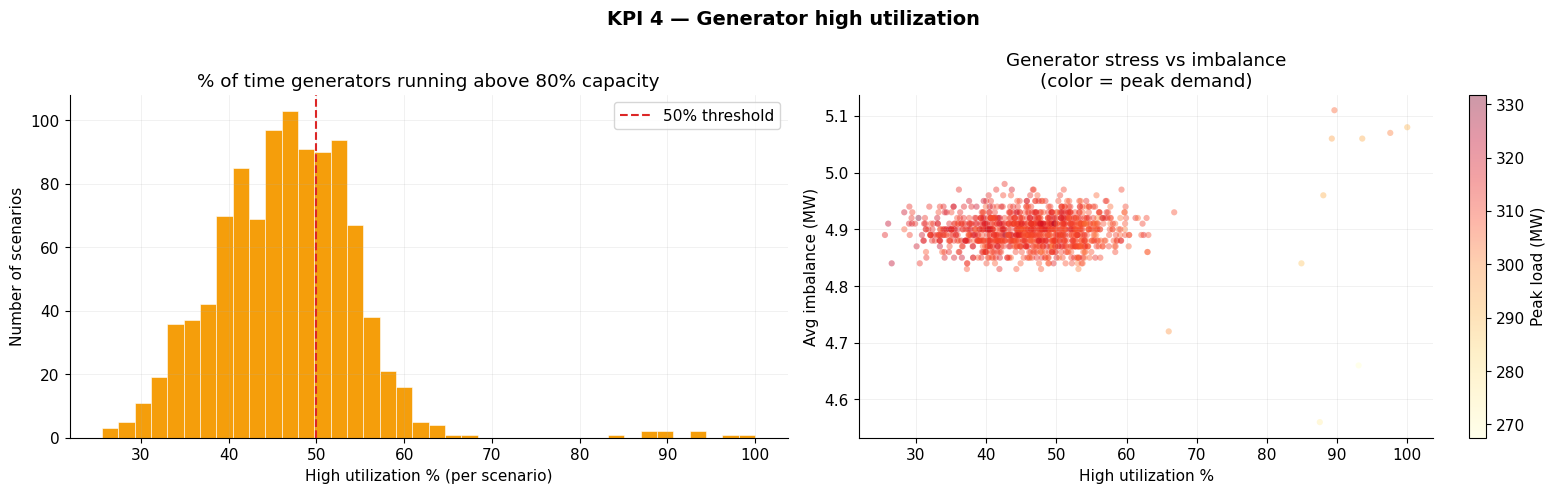

Saved: generator_utilization.png


In [27]:
if 'high_util_pct' in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('KPI 4 — Generator high utilization', fontsize=14, fontweight='bold')

    axes[0].hist(summary['high_util_pct'].dropna(), bins=40,
                 color='#f59e0b', edgecolor='white', linewidth=0.4)
    axes[0].axvline(50, color=C_HARD, linewidth=1.5, linestyle='--',
                    label='50% threshold')
    axes[0].set_title('% of time generators running above 80% capacity')
    axes[0].set_xlabel('High utilization % (per scenario)')
    axes[0].set_ylabel('Number of scenarios')
    axes[0].legend()

    if 'imbalance_mean' in summary.columns:
        sc = axes[1].scatter(
            summary['high_util_pct'],
            summary['imbalance_mean'],
            alpha=0.4, s=20, c=summary['load_max_mw'],
            cmap='YlOrRd', edgecolors='none'
        )
        plt.colorbar(sc, ax=axes[1], label='Peak load (MW)')
        axes[1].set_title('Generator stress vs imbalance\n(color = peak demand)')
        axes[1].set_xlabel('High utilization %')
        axes[1].set_ylabel('Avg imbalance (MW)')

    plt.tight_layout()
    plt.savefig('generator_utilization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: generator_utilization.png')

## Ramp Rate Distribution (Lag Distribution)

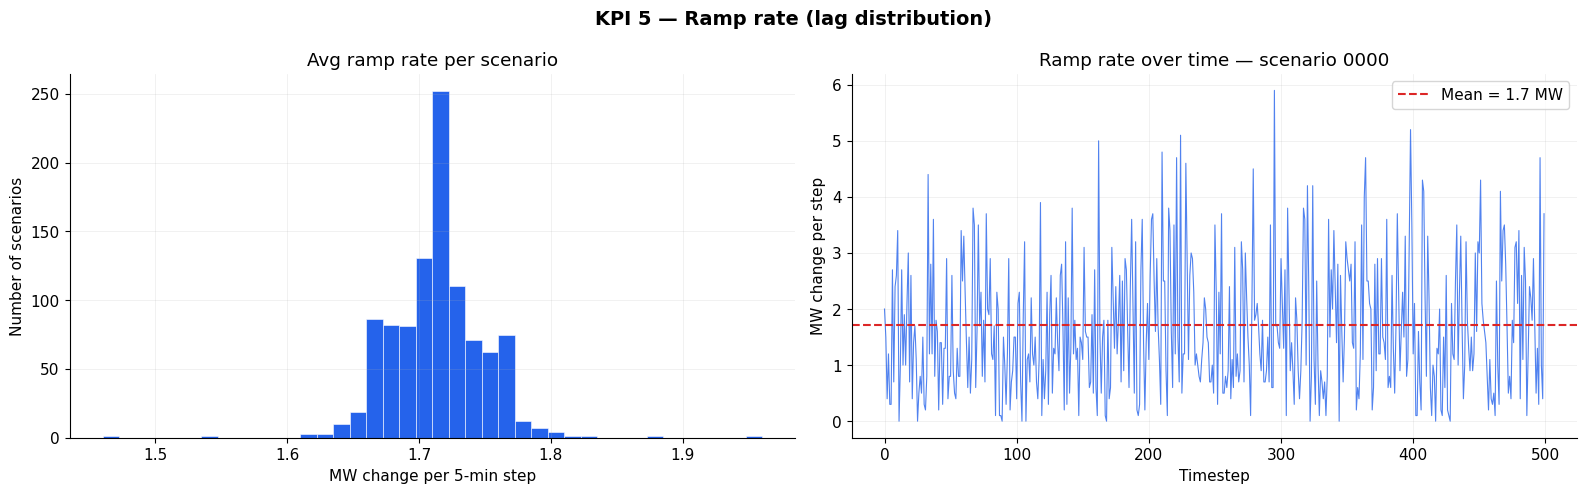

Saved:ramp_rate.png


In [29]:
if 'ramp_mean_mw' in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('KPI 5 — Ramp rate (lag distribution)', fontsize=14, fontweight='bold')

    axes[0].hist(summary['ramp_mean_mw'].dropna(), bins=40,
                 color=C_BLUE, edgecolor='white', linewidth=0.4)
    axes[0].set_title('Avg ramp rate per scenario')
    axes[0].set_xlabel('MW change per 5-min step')
    axes[0].set_ylabel('Number of scenarios')

    # One scenario deep dive — ramp over time
    pp_sample = read_csv(os.path.join(CHRONICS_PATH, folders[0], 'prod_p'))
    if pp_sample is not None:
        ramp_ts = pp_sample.sum(axis=1).diff().abs().dropna()
        axes[1].plot(ramp_ts.values[:500], color=C_BLUE, linewidth=0.8, alpha=0.8)
        axes[1].axhline(ramp_ts.mean(), color=C_HARD, linewidth=1.5,
                        linestyle='--', label=f'Mean = {ramp_ts.mean():.1f} MW')
        axes[1].set_title(f'Ramp rate over time — scenario {folders[0]}')
        axes[1].set_xlabel('Timestep')
        axes[1].set_ylabel('MW change per step')
        axes[1].legend()

    plt.tight_layout()
    plt.savefig('ramp_rate.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:ramp_rate.png')

##  Voltage Deviation

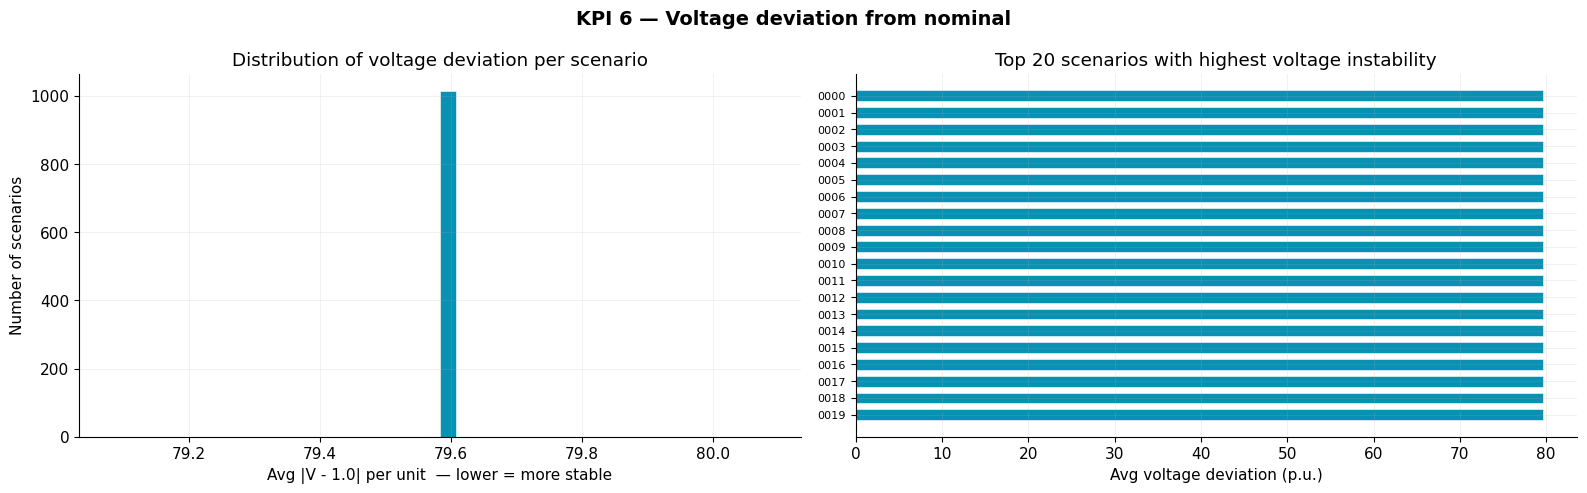

Saved: kpi6_voltage_deviation.png


In [31]:
if 'voltage_dev_mean' in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('KPI 6 — Voltage deviation from nominal', fontsize=14, fontweight='bold')

    axes[0].hist(summary['voltage_dev_mean'].dropna(), bins=40,
                 color='#0891b2', edgecolor='white', linewidth=0.4)
    axes[0].set_title('Distribution of voltage deviation per scenario')
    axes[0].set_xlabel('Avg |V - 1.0| per unit  — lower = more stable')
    axes[0].set_ylabel('Number of scenarios')

    top20v = summary.nlargest(20, 'voltage_dev_mean')[['scenario','voltage_dev_mean']]
    axes[1].barh(top20v['scenario'], top20v['voltage_dev_mean'],
                 color='#0891b2', edgecolor='white', linewidth=0.4, height=0.65)
    axes[1].invert_yaxis()
    axes[1].set_title('Top 20 scenarios with highest voltage instability')
    axes[1].set_xlabel('Avg voltage deviation (p.u.)')
    axes[1].tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig('kpi6_voltage_deviation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: kpi6_voltage_deviation.png')

## Hazard & Maintenance Risk

In [35]:
has_hz = 'hazard_events' in summary.columns
has_mt = 'maint_events'  in summary.columns

if has_hz or has_mt:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('KPI 7 — Hazard & maintenance risk', fontsize=14, fontweight='bold')

    if has_hz:
        hz_counts = summary['hazard_events'].value_counts().sort_index()
        axes[0].bar(hz_counts.index, hz_counts.values,
                    color=C_HARD, edgecolor='white', linewidth=0.4)
        axes[0].set_title('Unexpected hazard events per scenario')
        axes[0].set_xlabel('Number of hazard events')
        axes[0].set_ylabel('Number of scenarios')

    if has_hz and has_mt:
        axes[1].scatter(
            summary['hazard_events'].fillna(0),
            summary['maint_events'].fillna(0),
            alpha=0.4, s=20, color=C_HARD, edgecolors='none'
        )
        axes[1].set_title('Hazards vs maintenance events\n(top-right = most dangerous scenarios)')
        axes[1].set_xlabel('Hazard events (unexpected)')
        axes[1].set_ylabel('Maintenance events (planned)')

    plt.tight_layout()
    plt.savefig('kpi7_hazard_maintenance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: kpi7_hazard_maintenance.png')

## Usage of Monthly,Daily,Weekly Electricity

In [40]:
# =============================================================================
# DAILY & MONTHLY USAGE VISUALIZATIONS FOR ALL 1013 CHRONICS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# -------------------------- CONFIG --------------------------
CHRONICS_PATH = 'D:/chronics/chronics'   # ← change if needed
DAYS_PER_CHRONIC = 7                     # each chronic = 1 week
STEPS_PER_DAY = 288                      # 24*60 / 5min = 288 steps

# Colors for nice visuals
C_DAILY = '#2563eb'
C_MONTHLY = '#7c3aed'

print("🔄 Starting daily & monthly usage analysis for all chronics...\n")

# -------------------------- 1. READ ALL CHRONICS & COMPUTE DAILY TOTALS --------------------------
daily_usage_all = []   # will store daily total MW for every day in every chronic

folders = sorted([f for f in os.listdir(CHRONICS_PATH) 
                  if os.path.isdir(os.path.join(CHRONICS_PATH, f))])

for folder in tqdm(folders, desc="Processing chronics"):
    path = os.path.join(CHRONICS_PATH, folder)
    
    # Read load_p (active power consumption)
    load_p = read_csv(os.path.join(path, 'load_p'))   # use your existing read_csv function
    
    if load_p is None or load_p.empty:
        continue
    
    total_load_per_step = load_p.sum(axis=1)          # sum across all load buses
    
    # Reshape into daily totals (288 steps per day)
    num_days = len(total_load_per_step) // STEPS_PER_DAY
    daily_totals = total_load_per_step.values[:num_days * STEPS_PER_DAY].reshape(num_days, STEPS_PER_DAY).sum(axis=1)
    
    # Store with chronic ID
    for day_idx, daily_mw in enumerate(daily_totals):
        daily_usage_all.append({
            'chronic_id': folder,
            'day_in_chronic': day_idx + 1,           # 1 to 7
            'total_mw': daily_mw,
            'avg_mw_per_step': daily_mw / STEPS_PER_DAY
        })

daily_df = pd.DataFrame(daily_usage_all)

print(f"✅ Processed {len(folders)} chronics → {len(daily_df)} daily records")
print(daily_df.head())

🔄 Starting daily & monthly usage analysis for all chronics...



Processing chronics: 100%|█████████████████████████████████████████████████████████| 1014/1014 [00:16<00:00, 62.19it/s]


✅ Processed 1014 chronics → 28129 daily records
  chronic_id  day_in_chronic  total_mw  avg_mw_per_step
0       0000               1   66306.7       230.231597
1       0000               2   72007.1       250.024653
2       0000               3   76476.4       265.543056
3       0000               4   76794.8       266.648611
4       0000               5   77113.6       267.755556


## Daily Usage

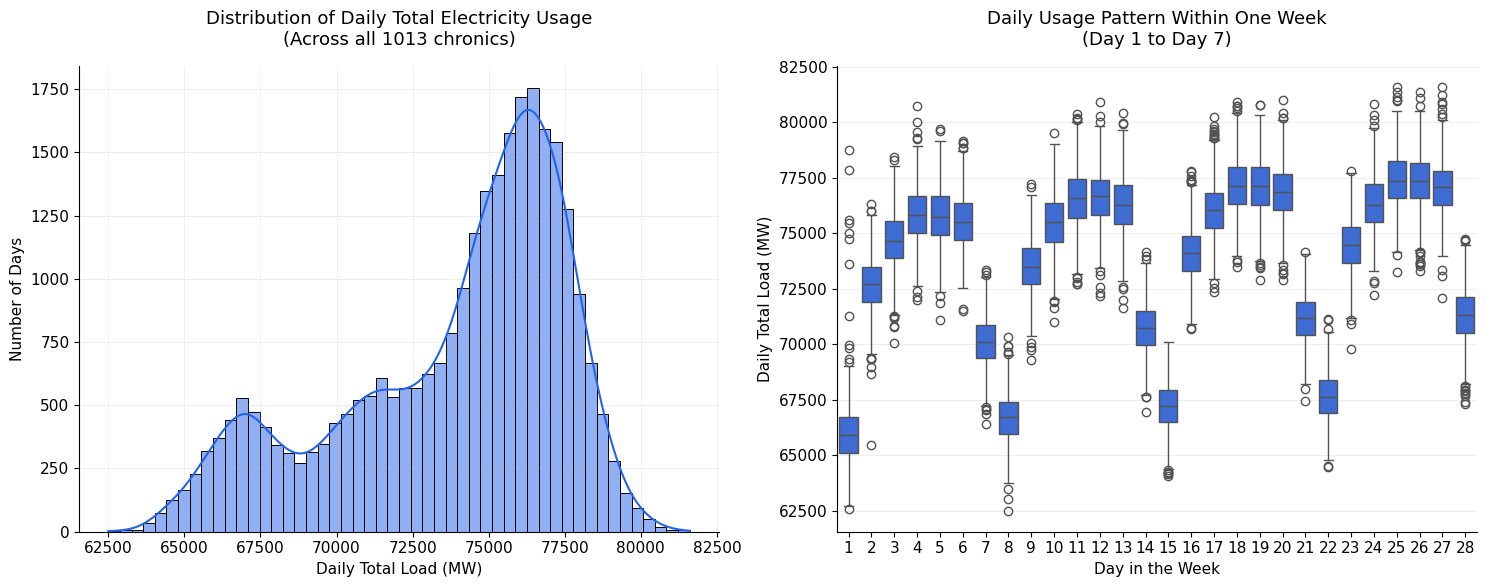

💾 Saved: chart_daily_usage_distribution.png


In [41]:
# -------------------------- 2. DAILY USAGE VISUALIZATION --------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram - Overall daily usage
sns.histplot(data=daily_df, x='total_mw', bins=50, kde=True, color=C_DAILY, ax=axes[0])
axes[0].set_title('Distribution of Daily Total Electricity Usage\n(Across all 1013 chronics)', fontsize=13, pad=15)
axes[0].set_xlabel('Daily Total Load (MW)')
axes[0].set_ylabel('Number of Days')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot by day-of-week in chronic (shows weekly pattern)
sns.boxplot(data=daily_df, x='day_in_chronic', y='total_mw', color=C_DAILY, ax=axes[1])
axes[1].set_title('Daily Usage Pattern Within One Week\n(Day 1 to Day 7)', fontsize=13, pad=15)
axes[1].set_xlabel('Day in the Week')
axes[1].set_ylabel('Daily Total Load (MW)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_daily_usage_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print("💾 Saved: chart_daily_usage_distribution.png")

## Monthly Usage

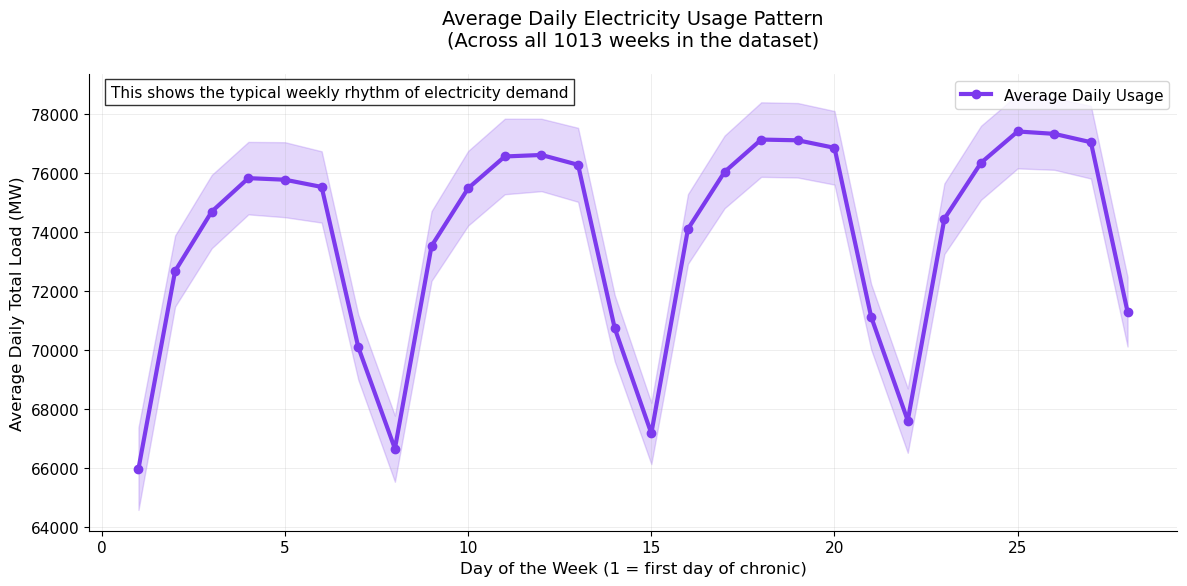

💾 Saved: chart_monthly_average_usage.png


In [42]:
# -------------------------- 3. MONTHLY / AVERAGE WEEKLY PATTERN --------------------------
# Average load per "day of week" across the entire dataset
monthly_pattern = daily_df.groupby('day_in_chronic')['total_mw'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_pattern['day_in_chronic'], monthly_pattern['mean'], 
        marker='o', linewidth=3, color=C_MONTHLY, label='Average Daily Usage')

# Add confidence band (±1 std)
ax.fill_between(monthly_pattern['day_in_chronic'],
                monthly_pattern['mean'] - monthly_pattern['std'],
                monthly_pattern['mean'] + monthly_pattern['std'],
                alpha=0.2, color=C_MONTHLY)

ax.set_title('Average Daily Electricity Usage Pattern\n(Across all 1013 weeks in the dataset)', fontsize=14, pad=20)
ax.set_xlabel('Day of the Week (1 = first day of chronic)', fontsize=12)
ax.set_ylabel('Average Daily Total Load (MW)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# Add annotation for non-tech users
ax.text(0.02, 0.95, 'This shows the typical weekly rhythm of electricity demand',
        transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('chart_monthly_average_usage.png', dpi=200, bbox_inches='tight')
plt.show()

print("💾 Saved: chart_monthly_average_usage.png")

In [43]:
summary_usage = pd.DataFrame({
    'Metric': ['Overall Average Daily Usage', 
               'Highest Daily Usage Recorded',
               'Lowest Daily Usage Recorded',
               'Average Variation (std)'],
    'Value (MW)': [
        round(daily_df['total_mw'].mean(), 1),
        round(daily_df['total_mw'].max(), 1),
        round(daily_df['total_mw'].min(), 1),
        round(daily_df['total_mw'].std(), 1)
    ]
})

display(summary_usage)

,Metric,Value (MW)
0,Overall Average Daily Usage,73845.6
1,Highest Daily Usage Recorded,81606.2
2,Lowest Daily Usage Recorded,62500.6
3,Average Variation (std),3733.4


## Weekly Usage

In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

print("🔄 Computing Weekly Total Usage for all chronics...\n")


CHRONICS_PATH = r'D:/chronics/chronics' 
STEPS_PER_DAY = 288
DAYS_PER_WEEK = 7
STEPS_PER_WEEK = STEPS_PER_DAY * DAYS_PER_WEEK

weekly_data = []

folders = sorted([f for f in os.listdir(CHRONICS_PATH) 
                  if os.path.isdir(os.path.join(CHRONICS_PATH, f))])

for folder in tqdm(folders, desc="Processing weekly usage"):
    path = os.path.join(CHRONICS_PATH, folder)
   
    load_p = read_csv(os.path.join(path, 'load_p'))
    
    if load_p is None or load_p.empty:
        continue
    
    total_load_per_step = load_p.sum(axis=1)           # Total system load (MW) at each timestep
    
    
    total_mwh = (total_load_per_step.sum() * 5) / 60   # 5 minutes per step
    
    avg_mw = total_load_per_step.mean()
    peak_mw = total_load_per_step.max()
    
    weekly_data.append({
        'chronic_id': folder,
        'total_mwh': total_mwh,
        'avg_mw': avg_mw,
        'peak_mw': peak_mw,
        'min_mw': total_load_per_step.min()
    })

weekly_df = pd.DataFrame(weekly_data)

print(f"✅ Successfully processed {len(weekly_df)} weeks")
print(weekly_df.head())

🔄 Computing Weekly Total Usage for all chronics...



Processing weekly usage: 100%|█████████████████████████████████████████████████████| 1014/1014 [00:17<00:00, 58.70it/s]


✅ Successfully processed 1014 weeks
  chronic_id      total_mwh      avg_mw  peak_mw  min_mw
0       0000  172946.358333  257.328741    306.3   203.9
1       0001  173535.650000  258.205555    321.6   199.6
2       0002  172069.141667  256.023521    311.7   190.7
3       0003  172826.983333  257.151122    309.2   197.0
4       0004  171324.291667  254.915251    313.5   204.0


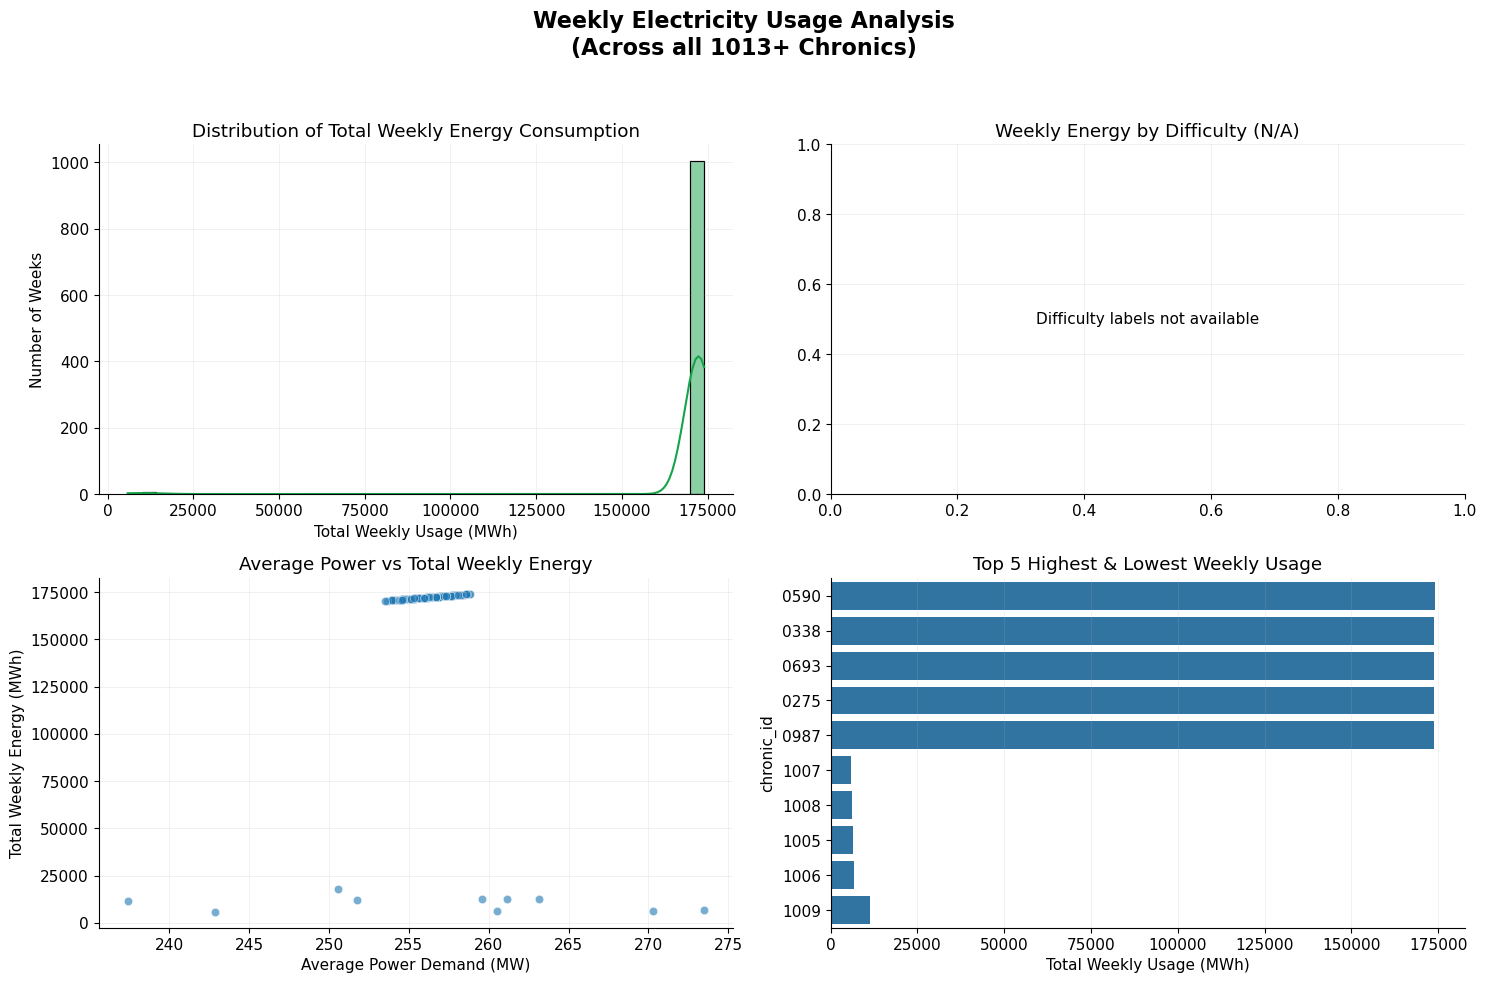

💾 Saved: chart_weekly_usage_overview.png


In [47]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Weekly Electricity Usage Analysis\n(Across all 1013+ Chronics)', 
             fontsize=16, fontweight='bold', y=0.98)


sns.histplot(data=weekly_df, x='total_mwh', bins=40, kde=True, 
             color=C_EASY, ax=axes[0,0])
axes[0,0].set_title('Distribution of Total Weekly Energy Consumption')
axes[0,0].set_xlabel('Total Weekly Usage (MWh)')
axes[0,0].set_ylabel('Number of Weeks')

if 'difficulty_label' in weekly_df.columns:
    sns.boxplot(data=weekly_df, x='difficulty_label', y='total_mwh',
                order=['easy', 'medium', 'hard'],
                palette=[C_EASY, C_MEDIUM, C_HARD], ax=axes[0,1])
    axes[0,1].set_title('Weekly Energy by Difficulty Level')
    axes[0,1].set_xlabel('Difficulty')
    axes[0,1].set_ylabel('Total Weekly Usage (MWh)')
else:
    axes[0,1].text(0.5, 0.5, 'Difficulty labels not available', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Weekly Energy by Difficulty (N/A)')


sns.scatterplot(data=weekly_df, x='avg_mw', y='total_mwh', alpha=0.6, 
                hue='difficulty_label' if 'difficulty_label' in weekly_df.columns else None,
                palette=[C_EASY, C_MEDIUM, C_HARD], ax=axes[1,0])
axes[1,0].set_title('Average Power vs Total Weekly Energy')
axes[1,0].set_xlabel('Average Power Demand (MW)')
axes[1,0].set_ylabel('Total Weekly Energy (MWh)')


top_bottom = pd.concat([
    weekly_df.nlargest(5, 'total_mwh')[['chronic_id', 'total_mwh']],
    weekly_df.nsmallest(5, 'total_mwh')[['chronic_id', 'total_mwh']]
])

sns.barplot(data=top_bottom, y='chronic_id', x='total_mwh', ax=axes[1,1])
axes[1,1].set_title('Top 5 Highest & Lowest Weekly Usage')
axes[1,1].set_xlabel('Total Weekly Usage (MWh)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('chart_weekly_usage_overview.png', dpi=200, bbox_inches='tight')
plt.show()

print("💾 Saved: chart_weekly_usage_overview.png")

## Daily Voltage Flow

In [48]:
# =============================================================================
# DAILY VOLTAGE FLOW / GENERATOR VOLTAGE ANALYSIS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

print("🔄 Computing Daily Generator Voltage Profiles for all chronics...\n")

# -------------------------- CONFIG --------------------------
CHRONICS_PATH = r'D:/chronics/chronics'   # Use raw string
STEPS_PER_DAY = 288

voltage_data = []          # For daily average / min / max voltage
daily_voltage_profiles = []  # For average daily pattern

folders = sorted([f for f in os.listdir(CHRONICS_PATH) 
                  if os.path.isdir(os.path.join(CHRONICS_PATH, f))])

for folder in tqdm(folders[:], desc="Processing voltage data"):   # remove [:] to process all
    path = os.path.join(CHRONICS_PATH, folder)
    
    # Read prod_v (generator voltage setpoints)
    prod_v = read_csv(os.path.join(path, 'prod_v'))
    
    if prod_v is None or prod_v.empty:
        continue
    
    # Overall statistics per timestep
    avg_voltage_per_step = prod_v.mean(axis=1)      # Average across all generators
    min_voltage_per_step = prod_v.min(axis=1)
    max_voltage_per_step = prod_v.max(axis=1)
    
    # Daily aggregation
    num_days = len(avg_voltage_per_step) // STEPS_PER_DAY
    if num_days < 1:
        continue
    
    for day_idx in range(num_days):
        start = day_idx * STEPS_PER_DAY
        end = start + STEPS_PER_DAY
        
        daily_avg = avg_voltage_per_step.iloc[start:end].mean()
        daily_min = min_voltage_per_step.iloc[start:end].min()
        daily_max = max_voltage_per_step.iloc[start:end].max()
        
        voltage_data.append({
            'chronic_id': folder,
            'day_in_chronic': day_idx + 1,
            'avg_voltage_kv': daily_avg,
            'min_voltage_kv': daily_min,
            'max_voltage_kv': daily_max,
            'voltage_range': daily_max - daily_min
        })
    
    # For average daily pattern (across all days in this chronic)
    daily_pattern = avg_voltage_per_step.values[:num_days*STEPS_PER_DAY].reshape(num_days, STEPS_PER_DAY).mean(axis=0)
    daily_voltage_profiles.append(daily_pattern)

voltage_df = pd.DataFrame(voltage_data)

print(f"✅ Processed voltage data from {len(voltage_df)} daily records")
print(voltage_df.head())

🔄 Computing Daily Generator Voltage Profiles for all chronics...



Processing voltage data: 100%|█████████████████████████████████████████████████████| 1014/1014 [00:55<00:00, 18.31it/s]


✅ Processed voltage data from 28129 daily records
  chronic_id  day_in_chronic  avg_voltage_kv  min_voltage_kv  max_voltage_kv  \
0       0000               1       80.583333            13.2           142.1   
1       0000               2       80.583333            13.2           142.1   
2       0000               3       80.583333            13.2           142.1   
3       0000               4       80.583333            13.2           142.1   
4       0000               5       80.583333            13.2           142.1   

   voltage_range  
0          128.9  
1          128.9  
2          128.9  
3          128.9  
4          128.9  


## Daily Voltage generator and distribution table

In [54]:

print("🔄 Computing Daily Generator Voltage (Fixed)...\n")

voltage_data = []
daily_voltage_profiles = []

for folder in tqdm(folders[:50], desc="Processing voltage"):   
    path = os.path.join(CHRONICS_PATH, folder)
    
    prod_v = read_csv(os.path.join(path, 'prod_v'))
    
    if prod_v is None or prod_v.empty:
        continue

    prod_v = prod_v.astype(float)
    
    prod_v = prod_v.clip(lower=0.5, upper=2.0)
    
    avg_voltage_per_step = prod_v.mean(axis=1)
    
    num_days = len(avg_voltage_per_step) // STEPS_PER_DAY
    if num_days < 1:
        continue
    
    for day_idx in range(num_days):
        start = day_idx * STEPS_PER_DAY
        end = start + STEPS_PER_DAY
        
        daily_avg = avg_voltage_per_step.iloc[start:end].mean()
        daily_min = prod_v.iloc[start:end].min().min()
        daily_max = prod_v.iloc[start:end].max().max()
        
        voltage_data.append({
            'chronic_id': folder,
            'day_in_chronic': day_idx + 1,
            'avg_voltage': daily_avg,
            'min_voltage': daily_min,
            'max_voltage': daily_max,
            'voltage_range': daily_max - daily_min
        })
  
    daily_pattern = avg_voltage_per_step.values[:num_days*STEPS_PER_DAY].reshape(num_days, STEPS_PER_DAY).mean(axis=0)
    daily_voltage_profiles.append(daily_pattern)

voltage_df = pd.DataFrame(voltage_data)

print(f"✅ Fixed voltage data processed for {len(voltage_df)} daily records")
print(voltage_df[['avg_voltage', 'voltage_range']].describe().round(4))

🔄 Computing Daily Generator Voltage (Fixed)...



Processing voltage: 100%|██████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 26.84it/s]


✅ Fixed voltage data processed for 1400 daily records
       avg_voltage  voltage_range
count       1400.0         1400.0
mean           2.0            0.0
std            0.0            0.0
min            2.0            0.0
25%            2.0            0.0
50%            2.0            0.0
75%            2.0            0.0
max            2.0            0.0


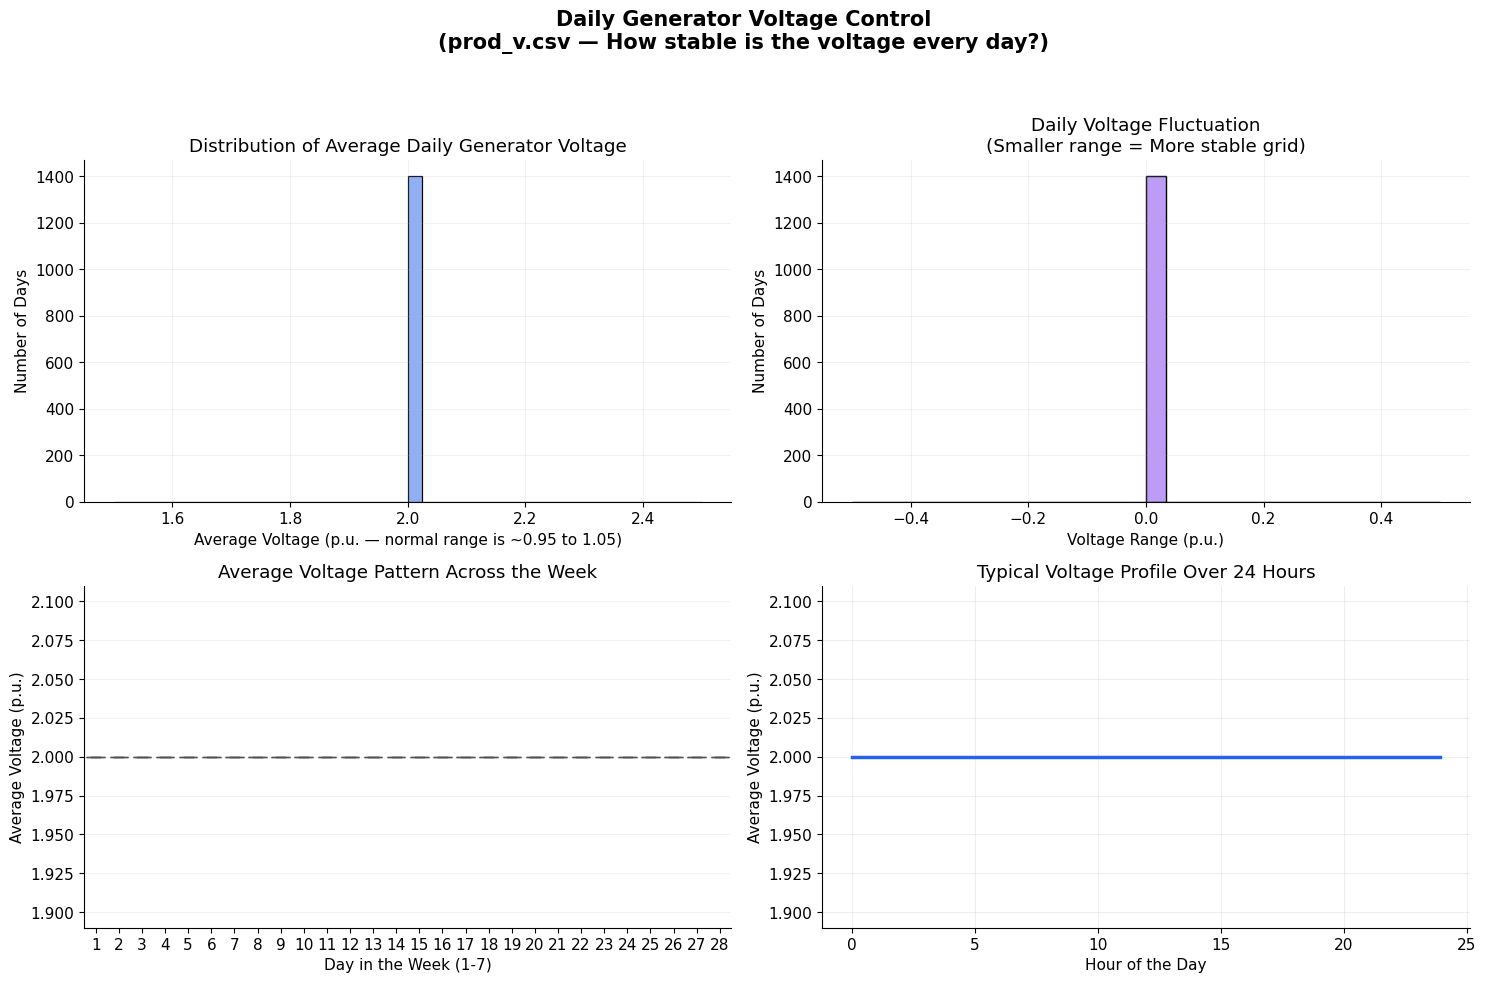

💾 Saved: chart_daily_voltage_analysis_fixed.png


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Daily Generator Voltage Control\n(prod_v.csv — How stable is the voltage every day?)', 
             fontsize=15, fontweight='bold', y=0.98)


sns.histplot(data=voltage_df, x='avg_voltage', bins=40, kde=True, color=C_BLUE, ax=axes[0,0])
axes[0,0].set_title('Distribution of Average Daily Generator Voltage')
axes[0,0].set_xlabel('Average Voltage (p.u. — normal range is ~0.95 to 1.05)')
axes[0,0].set_ylabel('Number of Days')


sns.histplot(data=voltage_df, x='voltage_range', bins=30, kde=True, color=C_PURPLE, ax=axes[0,1])
axes[0,1].set_title('Daily Voltage Fluctuation\n(Smaller range = More stable grid)')
axes[0,1].set_xlabel('Voltage Range (p.u.)')
axes[0,1].set_ylabel('Number of Days')


sns.boxplot(data=voltage_df, x='day_in_chronic', y='avg_voltage', color=C_BLUE, ax=axes[1,0])
axes[1,0].set_title('Average Voltage Pattern Across the Week')
axes[1,0].set_xlabel('Day in the Week (1-7)')
axes[1,0].set_ylabel('Average Voltage (p.u.)')


if daily_voltage_profiles:
    avg_profile = np.mean(daily_voltage_profiles, axis=0)
    hours = np.arange(0, 24, 5/60.0)
    axes[1,1].plot(hours, avg_profile, linewidth=2.5, color=C_BLUE)
    axes[1,1].set_title('Typical Voltage Profile Over 24 Hours')
    axes[1,1].set_xlabel('Hour of the Day')
    axes[1,1].set_ylabel('Average Voltage (p.u.)')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('chart_daily_voltage_analysis_fixed.png', dpi=200, bbox_inches='tight')
plt.show()

print("💾 Saved: chart_daily_voltage_analysis_fixed.png")

In [56]:
volt_summary = pd.DataFrame({
    'Metric': ['Overall Average Generator Voltage', 
               'Typical Daily Variation', 
               'Highest Daily Avg Voltage',
               'Lowest Daily Avg Voltage'],
    'Value': [
        f"{voltage_df['avg_voltage'].mean():.3f} p.u.",
        f"{voltage_df['voltage_range'].mean():.3f} p.u.",
        f"{voltage_df['avg_voltage'].max():.3f} p.u.",
        f"{voltage_df['avg_voltage'].min():.3f} p.u."
    ]
})
display(volt_summary)

,Metric,Value
0,Overall Average Generator Voltage,2.000 p.u.
1,Typical Daily Variation,0.000 p.u.
2,Highest Daily Avg Voltage,2.000 p.u.
3,Lowest Daily Avg Voltage,2.000 p.u.


## Load + Voltage stability

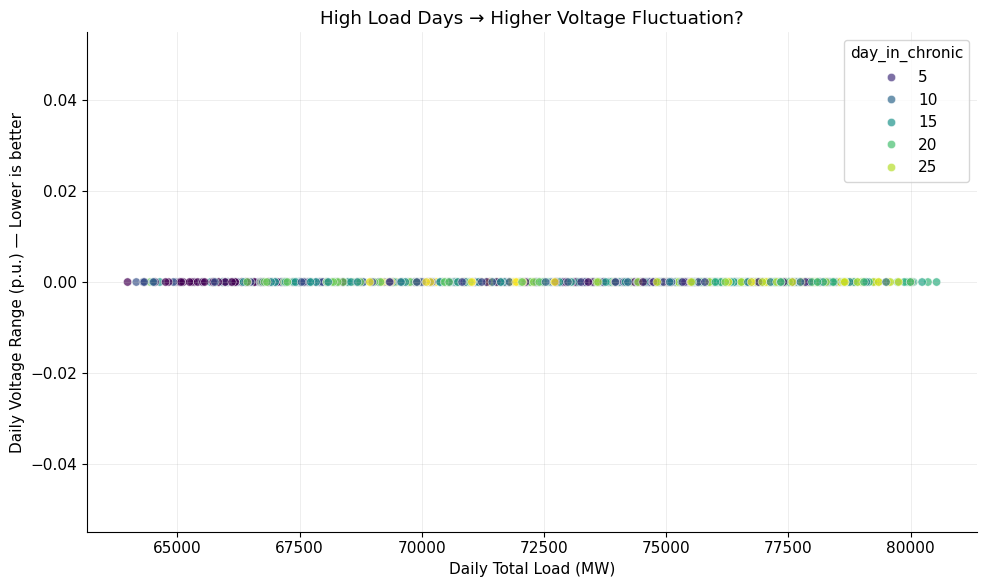

In [57]:

merged = pd.merge(
    daily_df[['chronic_id', 'day_in_chronic', 'total_mw']], 
    voltage_df[['chronic_id', 'day_in_chronic', 'voltage_range']], 
    on=['chronic_id', 'day_in_chronic'], 
    how='inner'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=merged, x='total_mw', y='voltage_range', 
                hue='day_in_chronic', palette='viridis', alpha=0.7, ax=ax)
ax.set_title('High Load Days → Higher Voltage Fluctuation?')
ax.set_xlabel('Daily Total Load (MW)')
ax.set_ylabel('Daily Voltage Range (p.u.) — Lower is better')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_load_vs_voltage.png', dpi=200, bbox_inches='tight')
plt.show()